# ML — Reclutamiento a Comisiones por Época Política
**Diputrax · 2026-04-21**

Tres targets · cuatro épocas · tres tiers de modelos · análisis SHAP.

| Comisión | Problema | Modelos |
|:---------|:---------|:--------|
| Nodales | Clasificación binaria (≥1) | LR → RF → XGBoost |
| Lastre | Clasificación binaria (≥1) | LR → RF → XGBoost |
| Temáticas | Regresión Poisson (conteo) | Poisson GLM → XGBoost Poisson |

| Era | Legislaturas | Partido | n |
|:----|:------------|:--------|--:|
| ERA_1 | LVII–LIX (57–59) | PRI hegemónico | 1500 |
| ERA_2 | LX–LXII (60–62) | Alternancia PAN | 1500 |
| ERA_3 | LXIII–LXV (63–65) | Transición | 1500 |
| ERA_4 | LXVI (66) | Morena | 500 |


## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score
from sklearn.metrics import roc_auc_score, mean_absolute_error
import xgboost as xgb
import shap

pd.set_option("display.float_format", "{:.3f}".format)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
print("All imports OK")
print(f"  xgboost {xgb.__version__}  |  shap {shap.__version__}")


All imports OK
  xgboost 3.2.0  |  shap 0.51.0


In [2]:
PARQUET = Path("data/database/clean/diputados_20260421_205712.parquet")

ERA_MAP = {
    57: "ERA_1_PRI",  58: "ERA_1_PRI",  59: "ERA_1_PRI",
    60: "ERA_2_PAN",  61: "ERA_2_PAN",  62: "ERA_2_PAN",
    63: "ERA_3_TRANS", 64: "ERA_3_TRANS", 65: "ERA_3_TRANS",
    66: "ERA_4_MORENA",
}
ERA_ORDER = ["ERA_1_PRI", "ERA_2_PAN", "ERA_3_TRANS", "ERA_4_MORENA"]
ERA_LABELS = {
    "ERA_1_PRI":    "ERA 1 — PRI (57-59)",
    "ERA_2_PAN":    "ERA 2 — PAN (60-62)",
    "ERA_3_TRANS":  "ERA 3 — Transicion (63-65)",
    "ERA_4_MORENA": "ERA 4 — Morena (66)",
}
ERA_COLORS = {
    "ERA_1_PRI":    "#c0392b",
    "ERA_2_PAN":    "#2980b9",
    "ERA_3_TRANS":  "#8e44ad",
    "ERA_4_MORENA": "#27ae60",
}

TOP_PARTIDOS = ["PRI", "PAN", "MORENA", "PRD", "PVEM", "PT", "MC"]


## 1. Carga y Feature Engineering

In [3]:
raw = pd.read_parquet(PARQUET)
print(f"Shape: {raw.shape}")
raw[["legislatura_num", "partido", "es_partido_mayoria",
     "n_comisiones_nodales", "n_comisiones_tematicas", "n_comisiones_lastre"]].head(3)


Shape: (5000, 78)


,legislatura_num,partido,es_partido_mayoria,n_comisiones_nodales,n_comisiones_tematicas,n_comisiones_lastre
0,59,PRI,1,1,1,1
1,59,PRI,1,0,2,0
2,59,PRI,1,1,1,0


In [4]:
df = raw.copy()

# Era
df["era"] = df["legislatura_num"].map(ERA_MAP)

# Targets binarios
df["nodal_bin"] = (df["n_comisiones_nodales"] >= 1).astype(int)
df["lastre_bin"] = (df["n_comisiones_lastre"] >= 1).astype(int)

# Imputar edad por legislatura
df["edad_imp"] = (df.groupby("legislatura_num")["edad_al_tomar_cargo"]
                    .transform(lambda x: x.fillna(x.mean())))
df["edad_missing"] = df["edad_al_tomar_cargo"].isna().astype(int)

# Region geografica
REGION_MAP = {
    "CDMX": "CDMX",
    **dict.fromkeys(["MEX","HGO","MOR","PUE","TLAX","QRO","GTO","AGS"], "CENTRO"),
    **dict.fromkeys(["VER","OAX","CHIS","TAB","GRO","CAM","YUC","QROO"], "SUR"),
    **dict.fromkeys(["NL","TAMPS","COAH","CHIH","SON","BC","BCS","SIN",
                     "DGO","ZAC","SLP","NAY"], "NORTE"),
    **dict.fromkeys(["JAL","COL","MICH"], "OCCIDENTE"),
    "DESCONOCIDO": "RP",
}
df["region"] = df["entidad_codigo"].map(REGION_MAP).fillna("CENTRO")

# Partido simplificado
df["partido_cat"] = df["partido"].where(df["partido"].isin(TOP_PARTIDOS), "OTRO")

# Features compuestas
df["carrera_depth"]      = (df["n_trayectoria_admin"]
                             + df["n_trayectoria_politica"]
                             + df["n_trayectoria_legislativa"])
df["edu_calidad"]        = (df["grado_estudios_ord"]
                             + df["tiene_posgrado"]
                             + df["estudios_en_extranjero"])
df["exp_alta_jerarquia"] = df[["fue_secretario_cargo",
                                "fue_director_general",
                                "fue_subsecretario"]].max(axis=1)
df["univ_elite"]         = df[["acad_unam","acad_itam",
                                "acad_ibero","acad_itesm"]].max(axis=1)

# One-hot encoding
_p    = pd.get_dummies(df["partido_cat"],     prefix="p")
_reg  = pd.get_dummies(df["region"],          prefix="reg")
_area = pd.get_dummies(df["area_formacion"],  prefix="area")
df_enc = pd.concat([df, _p, _reg, _area], axis=1)

print("Feature engineering OK")
print(df["era"].value_counts().sort_index().to_string())
print(f"\nTarget rates:")
for t in ["nodal_bin", "lastre_bin", "n_comisiones_tematicas"]:
    print(f"  {t}: {df[t].mean():.3f}")


Feature engineering OK
era
ERA_1_PRI       1500
ERA_2_PAN       1500
ERA_3_TRANS     1500
ERA_4_MORENA     500

Target rates:
  nodal_bin: 0.423
  lastre_bin: 0.453
  n_comisiones_tematicas: 1.868


In [5]:
NUMERIC_FEATS = [
    "edad_imp", "edad_missing",
    "mayoria_relativa", "es_partido_mayoria", "legislatura_num",
    "grado_estudios_ord", "tiene_posgrado", "tiene_doctorado",
    "estudios_en_extranjero", "univ_publica", "univ_privada", "univ_extranjera",
    "acad_unam","acad_itesm","acad_itam","acad_ibero",
    "acad_udg","acad_ipn","acad_uam","acad_anahuac","acad_uanl","acad_uv",
    "n_cargos_legislativos_prev", "fue_diputado_local",
    "fue_diputado_federal", "fue_senador", "n_trayectoria_legislativa",
    "n_trayectoria_admin", "nivel_cargo_max",
    "fue_presidente_mun", "fue_presidente_org", "fue_director_general",
    "fue_secretario_cargo", "fue_subsecretario", "fue_director",
    "fue_coordinador", "fue_delegado", "fue_asesor", "fue_regidor", "fue_sindico",
    "admin_en_partido","admin_en_sindicato","admin_en_universidad",
    "admin_en_gobierno_fed","admin_en_gobierno_est","admin_en_gobierno_mun",
    "n_trayectoria_politica", "tiene_exp_juvenil",
    "lider_juvenil_partido","lider_juvenil_gobierno","miembro_org_juvenil",
    "nivel_liderazgo_juvenil",
    "n_trayectoria_empresarial","n_investigacion_docencia","n_organos_gobierno",
    "carrera_depth","edu_calidad","exp_alta_jerarquia","univ_elite",
]
DUMMY_FEATS = list(_p.columns) + list(_reg.columns) + list(_area.columns)
FEAT_COLS   = NUMERIC_FEATS + DUMMY_FEATS
print(f"Features totales: {len(FEAT_COLS)}")


Features totales: 86


## 2. Infraestructura de Modelado

In [6]:
def get_Xy(era, target):
    mask = df_enc["era"] == era
    X = df_enc.loc[mask, FEAT_COLS].astype(float).reset_index(drop=True)
    y = df_enc.loc[mask, target].astype(float).reset_index(drop=True)
    return X, y

def spw(y):
    """scale_pos_weight para XGBoost (ratio neg/pos)."""
    n0 = float((y == 0).sum())
    n1 = float((y == 1).sum())
    return n0 / max(n1, 1.0)

# Model factories ─────────────────────────────────────────────────────────────
def lr_binary():
    return Pipeline([
        ("sc", StandardScaler()),
        ("lr", LogisticRegression(C=0.1, max_iter=3000,
                                  class_weight="balanced", random_state=42)),
    ])

def lr_poisson():
    return Pipeline([
        ("sc", StandardScaler()),
        ("pr", PoissonRegressor(alpha=1.0, max_iter=3000)),
    ])

def rf_binary():
    return RandomForestClassifier(
        n_estimators=500, max_depth=6, min_samples_leaf=15,
        max_features="sqrt", class_weight="balanced",
        n_jobs=-1, random_state=42,
    )

def make_xgb_binary(scale_pos_weight=1.0):
    return xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="auc", verbosity=0,
        n_jobs=-1, random_state=42,
    )

def make_xgb_poisson():
    return xgb.XGBRegressor(
        objective="count:poisson",
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        verbosity=0, n_jobs=-1, random_state=42,
    )

# CV helpers ──────────────────────────────────────────────────────────────────
def cv_auc(model, X, y, k=5):
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    s  = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
    return s.mean(), s.std()

def cv_mae(model, X, y, k=5):
    cv = KFold(n_splits=k, shuffle=True, random_state=42)
    s  = -cross_val_score(model, X, y, cv=cv, scoring="neg_mean_absolute_error")
    return s.mean(), s.std()

# SHAP helper — renders to PNG buffer to allow subplot grid ───────────────────
def shap_beeswarm_to_img(sv, X, top_n=15, title="", color="#333333"):
    """Returns a PNG image (numpy array) of a SHAP beeswarm."""
    top_idx = np.argsort(np.abs(sv).mean(axis=0))[-top_n:][::-1]
    fig, ax = plt.subplots(figsize=(8, 6))
    shap.summary_plot(sv[:, top_idx], X.iloc[:, top_idx],
                      plot_type="dot", show=False, max_display=top_n,
                      color_bar=True)
    ax = plt.gca()
    ax.set_title(title, fontsize=11, fontweight="bold", color=color)
    ax.set_xlabel("SHAP value")
    buf = io.BytesIO()
    plt.savefig(buf, format="png", bbox_inches="tight", dpi=100)
    plt.close()
    buf.seek(0)
    return mpimg.imread(buf)

print("Helpers definidos.")


Helpers definidos.


## 3. Comisiones Nodales — Clasificación Binaria

**Target:** `nodal_bin` = 1 si el diputado tiene ≥1 comisión nodal.
Hipótesis: se asignan a diputados experimentados del partido mayoritario.


In [7]:
print("Entrenando modelos para NODALES...")
rows_nodal = []

for era in ERA_ORDER:
    X, y = get_Xy(era, "nodal_bin")
    w = spw(y)

    lr_mu,  lr_sd  = cv_auc(lr_binary(), X, y)
    rf_mu,  rf_sd  = cv_auc(rf_binary(), X, y)
    xg_mu,  xg_sd  = cv_auc(make_xgb_binary(w), X, y)

    best = max(lr_mu, rf_mu, xg_mu)
    rows_nodal.append({
        "Era": ERA_LABELS[era], "n": len(y), "pos%": f"{y.mean():.1%}",
        "LR":  f"{lr_mu:.3f}+-{lr_sd:.3f}",
        "RF":  f"{rf_mu:.3f}+-{rf_sd:.3f}",
        "XGB": f"{xg_mu:.3f}+-{xg_sd:.3f}",
        "best": "LR" if best==lr_mu else ("RF" if best==rf_mu else "XGB"),
    })
    print(f"  {era:<18} LR={lr_mu:.3f} RF={rf_mu:.3f} XGB={xg_mu:.3f}")

df_nodal_cv = pd.DataFrame(rows_nodal)
df_nodal_cv


Entrenando modelos para NODALES...


  ERA_1_PRI          LR=0.734 RF=0.719 XGB=0.719


  ERA_2_PAN          LR=0.720 RF=0.725 XGB=0.718


  ERA_3_TRANS        LR=0.699 RF=0.677 XGB=0.694


  ERA_4_MORENA       LR=0.619 RF=0.643 XGB=0.602


,Era,n,pos%,LR,RF,XGB,best
0,ERA 1 — PRI (57-59),1500,32.2%,0.734+-0.025,0.719+-0.030,0.719+-0.033,LR
1,ERA 2 — PAN (60-62),1500,40.7%,0.720+-0.026,0.725+-0.026,0.718+-0.024,RF
2,ERA 3 — Transicion (63-65),1500,49.5%,0.699+-0.017,0.677+-0.028,0.694+-0.013,LR
3,ERA 4 — Morena (66),500,55.4%,0.619+-0.059,0.643+-0.064,0.602+-0.071,RF


### 3.1 SHAP — Beeswarm por era (Nodales)

In [8]:
shap_nodal   = {}
models_nodal = {}

for era in ERA_ORDER:
    X, y = get_Xy(era, "nodal_bin")
    m = make_xgb_binary(spw(y))
    m.fit(X, y)
    models_nodal[era] = m
    sv = shap.TreeExplainer(m).shap_values(X)
    shap_nodal[era] = (sv, X)
    print(f"  {era}: SHAP OK  (shape={sv.shape})")


  ERA_1_PRI: SHAP OK  (shape=(1500, 86))


  ERA_2_PAN: SHAP OK  (shape=(1500, 86))


  ERA_3_TRANS: SHAP OK  (shape=(1500, 86))
  ERA_4_MORENA: SHAP OK  (shape=(500, 86))


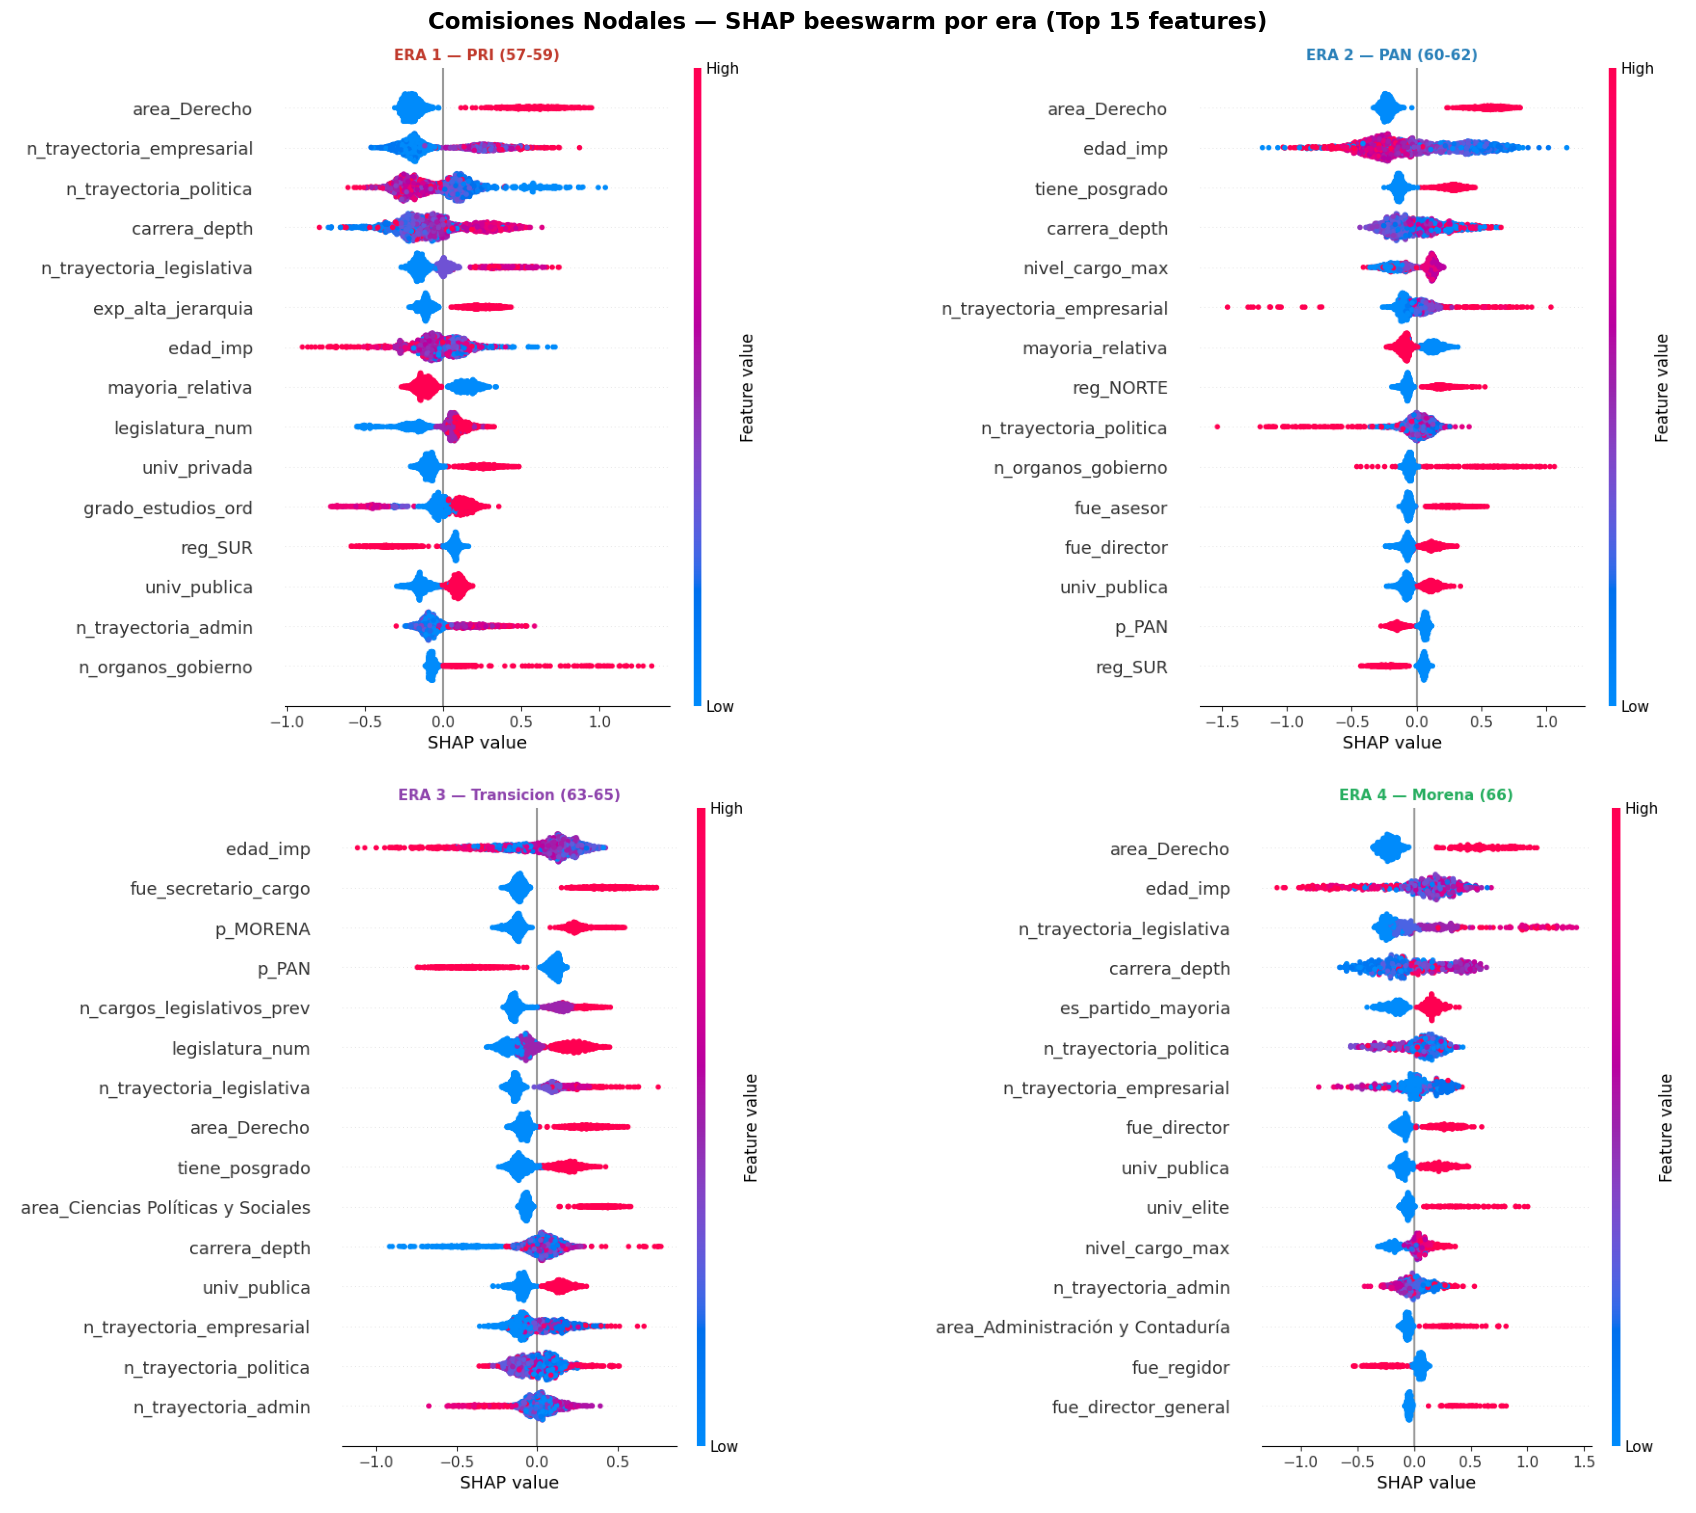

In [9]:
# Beeswarm grid 2x2 — via PNG buffers para evitar conflictos de axes
imgs = {era: shap_beeswarm_to_img(
            *shap_nodal[era], top_n=15,
            title=ERA_LABELS[era], color=ERA_COLORS[era])
        for era in ERA_ORDER}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
for ax, era in zip(axes.flatten(), ERA_ORDER):
    ax.imshow(imgs[era])
    ax.axis("off")

plt.suptitle("Comisiones Nodales — SHAP beeswarm por era (Top 15 features)",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/eda/shap_nodales_beeswarm.png", bbox_inches="tight", dpi=120)
plt.show()


### 3.2 Heatmap de importancias SHAP por era

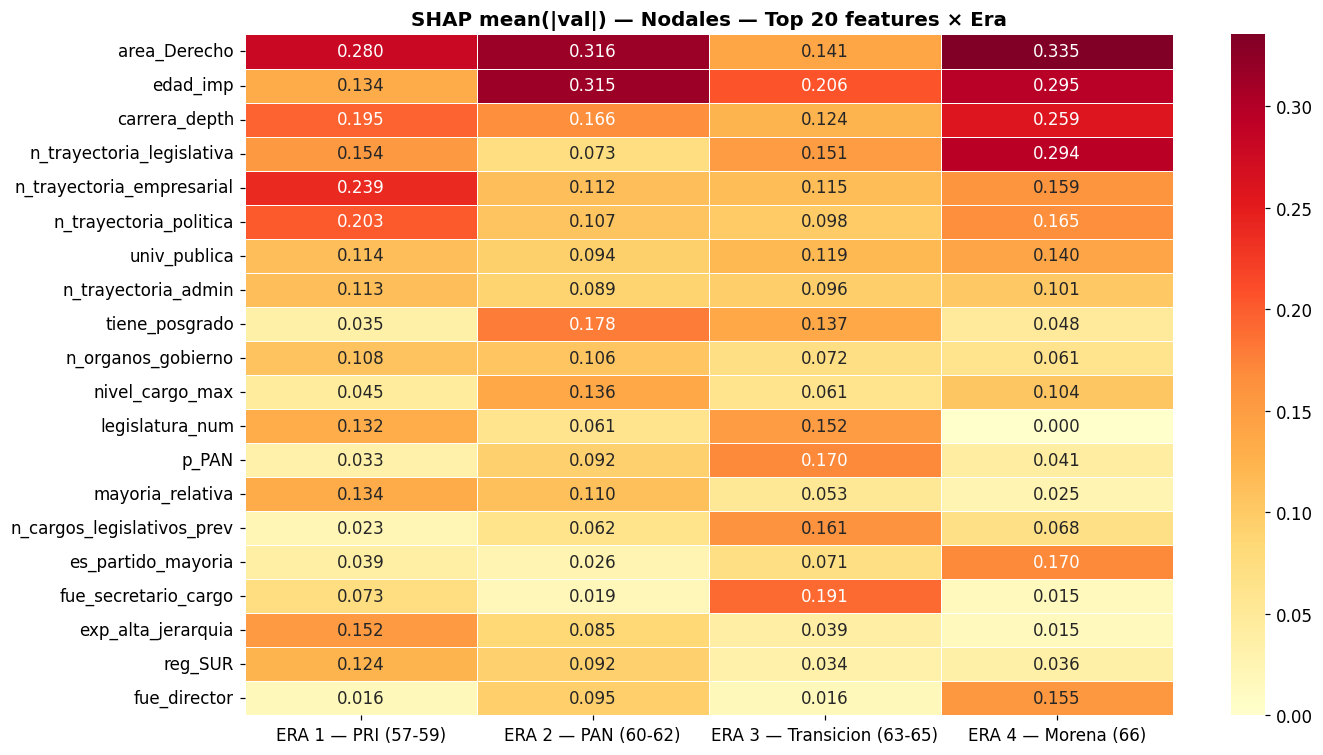

,ERA 1 — PRI (57-59),ERA 2 — PAN (60-62),ERA 3 — Transicion (63-65),ERA 4 — Morena (66),MEDIA
area_Derecho,0.280,0.316,0.140,0.335,0.268
edad_imp,0.134,0.315,0.206,0.295,0.238
carrera_depth,0.196,0.166,0.124,0.259,0.186
n_trayectoria_legislativa,0.154,0.073,0.151,0.294,0.168
n_trayectoria_empresarial,0.239,0.112,0.115,0.159,0.156
n_trayectoria_politica,0.203,0.107,0.098,0.165,0.143
univ_publica,0.114,0.094,0.119,0.140,0.117
n_trayectoria_admin,0.113,0.089,0.096,0.101,0.100
tiene_posgrado,0.035,0.178,0.137,0.048,0.100
n_organos_gobierno,0.108,0.106,0.072,0.061,0.087


In [10]:
imp_nodal = {era: pd.Series(np.abs(shap_nodal[era][0]).mean(axis=0), index=FEAT_COLS)
             for era in ERA_ORDER}

df_imp_n = pd.DataFrame(imp_nodal).rename(columns=ERA_LABELS)
df_imp_n["MEDIA"] = df_imp_n.mean(axis=1)
df_imp_n = df_imp_n.sort_values("MEDIA", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(13, 7))
plot_cols = [ERA_LABELS[e] for e in ERA_ORDER]
sns.heatmap(df_imp_n[plot_cols], annot=True, fmt=".3f",
            cmap="YlOrRd", ax=ax, linewidths=0.4)
ax.set_title("SHAP mean(|val|) — Nodales — Top 20 features × Era",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/eda/shap_nodales_heatmap.png", bbox_inches="tight", dpi=120)
plt.show()

df_imp_n.round(4)


### 3.3 Evolución temporal de features clave

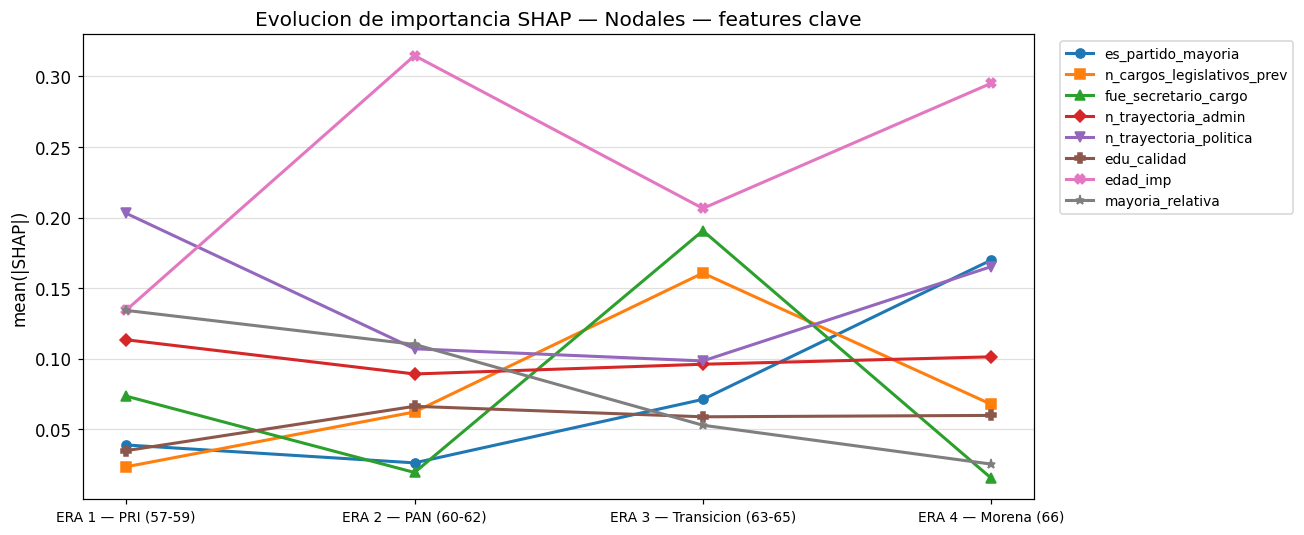

,ERA 1 — PRI (57-59),ERA 2 — PAN (60-62),ERA 3 — Transicion (63-65),ERA 4 — Morena (66)
es_partido_mayoria,0.039,0.026,0.071,0.170
n_cargos_legislativos_prev,0.023,0.062,0.161,0.068
fue_secretario_cargo,0.073,0.019,0.191,0.015
n_trayectoria_admin,0.113,0.089,0.096,0.101
n_trayectoria_politica,0.203,0.107,0.098,0.165
edu_calidad,0.035,0.066,0.059,0.060
edad_imp,0.134,0.315,0.206,0.295
mayoria_relativa,0.134,0.110,0.053,0.025


In [11]:
KEY_FEATS = [
    "es_partido_mayoria", "n_cargos_legislativos_prev",
    "fue_secretario_cargo", "n_trayectoria_admin",
    "n_trayectoria_politica", "edu_calidad",
    "edad_imp", "mayoria_relativa",
]

imp_raw_n = {era: pd.Series(np.abs(shap_nodal[era][0]).mean(axis=0), index=FEAT_COLS)
             for era in ERA_ORDER}
df_trend_n = pd.DataFrame(
    {f: [imp_raw_n[e][f] for e in ERA_ORDER] for f in KEY_FEATS},
    index=[ERA_LABELS[e] for e in ERA_ORDER]
)

fig, ax = plt.subplots(figsize=(12, 5))
markers = ["o","s","^","D","v","P","X","*"]
for i, feat in enumerate(KEY_FEATS):
    ax.plot(range(4), df_trend_n[feat], marker=markers[i],
            linewidth=2, label=feat)

ax.set_xticks(range(4))
ax.set_xticklabels([ERA_LABELS[e] for e in ERA_ORDER], fontsize=9)
ax.set_ylabel("mean(|SHAP|)")
ax.set_title("Evolucion de importancia SHAP — Nodales — features clave")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("reports/eda/shap_nodales_trend.png", bbox_inches="tight", dpi=120)
plt.show()

df_trend_n.T.round(4)


## 4. Comisiones Lastre — Clasificación Binaria

**Target:** `lastre_bin` = 1 si el diputado tiene ≥1 comision lastre.
**Hipotesis:** perfil inverso a nodales — primera legislatura, sin experiencia, minoria.


In [12]:
print("Entrenando modelos para LASTRE...")
rows_lastre = []

for era in ERA_ORDER:
    X, y = get_Xy(era, "lastre_bin")
    w = spw(y)

    lr_mu,  lr_sd  = cv_auc(lr_binary(), X, y)
    rf_mu,  rf_sd  = cv_auc(rf_binary(), X, y)
    xg_mu,  xg_sd  = cv_auc(make_xgb_binary(w), X, y)

    best = max(lr_mu, rf_mu, xg_mu)
    rows_lastre.append({
        "Era": ERA_LABELS[era], "n": len(y), "pos%": f"{y.mean():.1%}",
        "LR":  f"{lr_mu:.3f}+-{lr_sd:.3f}",
        "RF":  f"{rf_mu:.3f}+-{rf_sd:.3f}",
        "XGB": f"{xg_mu:.3f}+-{xg_sd:.3f}",
        "best": "LR" if best==lr_mu else ("RF" if best==rf_mu else "XGB"),
    })
    print(f"  {era:<18} LR={lr_mu:.3f} RF={rf_mu:.3f} XGB={xg_mu:.3f}")

df_lastre_cv = pd.DataFrame(rows_lastre)
df_lastre_cv


Entrenando modelos para LASTRE...


  ERA_1_PRI          LR=0.585 RF=0.601 XGB=0.585


  ERA_2_PAN          LR=0.632 RF=0.618 XGB=0.589


  ERA_3_TRANS        LR=0.583 RF=0.617 XGB=0.606


  ERA_4_MORENA       LR=0.530 RF=0.595 XGB=0.557


,Era,n,pos%,LR,RF,XGB,best
0,ERA 1 — PRI (57-59),1500,42.1%,0.585+-0.017,0.601+-0.021,0.585+-0.012,RF
1,ERA 2 — PAN (60-62),1500,45.9%,0.632+-0.039,0.618+-0.020,0.589+-0.030,LR
2,ERA 3 — Transicion (63-65),1500,49.9%,0.583+-0.021,0.617+-0.026,0.606+-0.013,RF
3,ERA 4 — Morena (66),500,39.2%,0.530+-0.035,0.595+-0.064,0.557+-0.060,RF


In [13]:
shap_lastre   = {}
models_lastre = {}

for era in ERA_ORDER:
    X, y = get_Xy(era, "lastre_bin")
    m = make_xgb_binary(spw(y))
    m.fit(X, y)
    models_lastre[era] = m
    sv = shap.TreeExplainer(m).shap_values(X)
    shap_lastre[era] = (sv, X)
    print(f"  {era}: SHAP OK")


  ERA_1_PRI: SHAP OK


  ERA_2_PAN: SHAP OK


  ERA_3_TRANS: SHAP OK
  ERA_4_MORENA: SHAP OK


### 4.1 Nodales vs Lastre — Test de imagen espejo

In [14]:
# Correlacion SHAP(nodal) vs -SHAP(lastre) por era
corr_mirror = {}
for era in ERA_ORDER:
    sv_n = pd.Series(np.abs(shap_nodal[era][0]).mean(axis=0),  index=FEAT_COLS)
    sv_l = pd.Series(np.abs(shap_lastre[era][0]).mean(axis=0), index=FEAT_COLS)
    corr_mirror[era] = sv_n.corr(-sv_l)

print("Correlacion SHAP(nodal) vs -SHAP(lastre):")
print("Si r ~ 1.0 -> imagen espejo exacta (asignacion por exclusion, no seleccion positiva)")
print()
for era, c in corr_mirror.items():
    bar = "=" * int(abs(c) * 30)
    print(f"  {ERA_LABELS[era]:<30}  r = {c:+.3f}  |{bar}|")


Correlacion SHAP(nodal) vs -SHAP(lastre):
Si r ~ 1.0 -> imagen espejo exacta (asignacion por exclusion, no seleccion positiva)

  ERA 1 — PRI (57-59)             r = -0.588  |=================|
  ERA 2 — PAN (60-62)             r = -0.677  |====================|
  ERA 3 — Transicion (63-65)      r = -0.558  |================|
  ERA 4 — Morena (66)             r = -0.577  |=================|


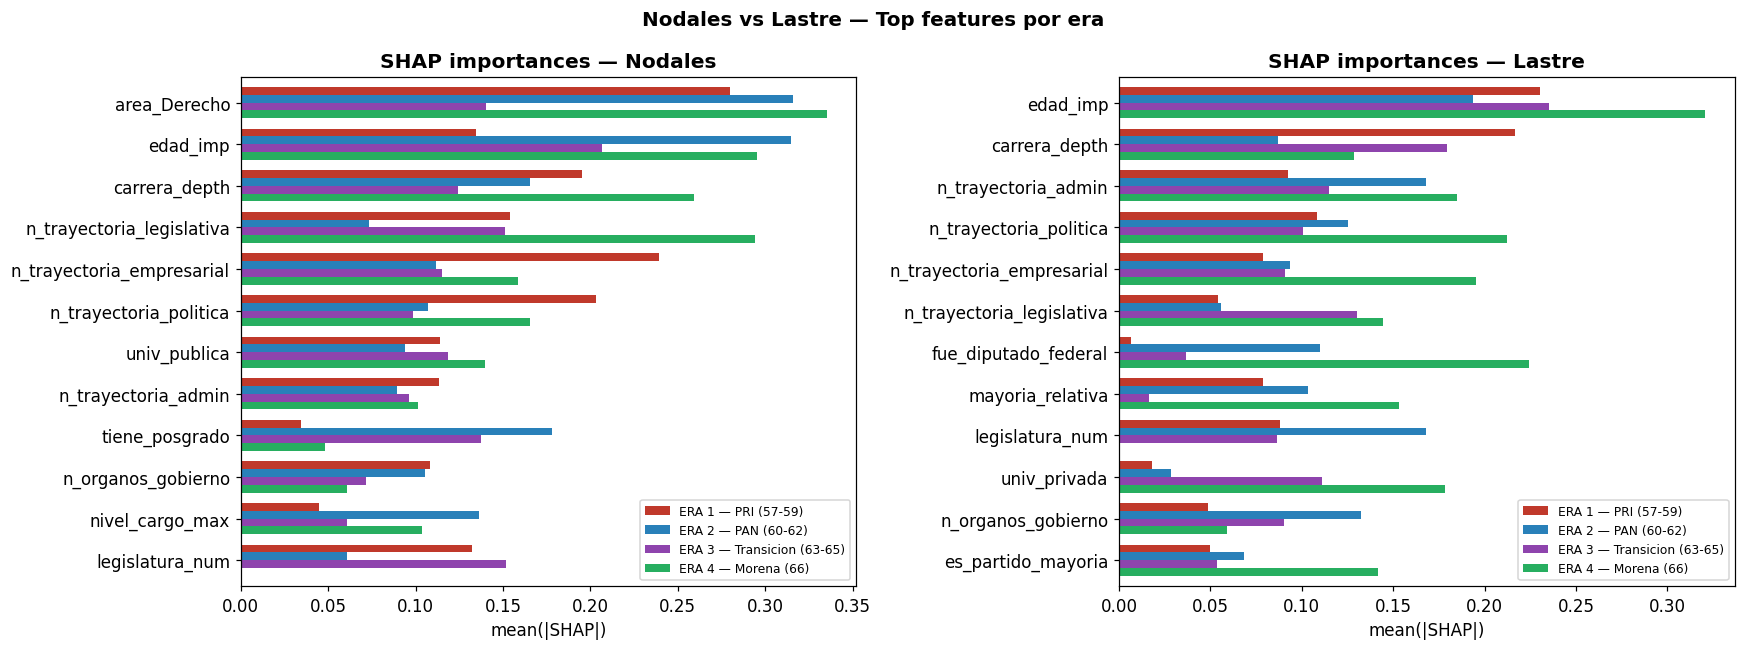

In [15]:
# Barplot comparativo top features nodal vs lastre
TOP_N = 12

def top_avg_imp(shap_dict, n=TOP_N):
    """Mean importance across all eras for top-n features."""
    all_imp = pd.DataFrame(
        {era: pd.Series(np.abs(sv).mean(axis=0), index=FEAT_COLS)
         for era, (sv, _) in shap_dict.items()}
    )
    return all_imp.mean(axis=1).nlargest(n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (sd, label, color) in zip(
    axes,
    [(shap_nodal, "Nodales", "#e74c3c"),
     (shap_lastre,"Lastre",  "#3498db")],
):
    top = top_avg_imp(sd)
    era_data = {ERA_LABELS[era]:
                pd.Series(np.abs(shap_data[0]).mean(axis=0), index=FEAT_COLS).reindex(top.index).fillna(0)
                for era, shap_data in sd.items()}
    df_plot = pd.DataFrame(era_data)
    df_plot.plot(kind="barh", ax=ax, width=0.75,
                 color=[ERA_COLORS[e] for e in ERA_ORDER])
    ax.set_title(f"SHAP importances — {label}", fontweight="bold")
    ax.set_xlabel("mean(|SHAP|)")
    ax.legend(fontsize=8)
    ax.invert_yaxis()

plt.suptitle("Nodales vs Lastre — Top features por era", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/eda/shap_nodal_vs_lastre.png", bbox_inches="tight", dpi=120)
plt.show()


## 5. Comisiones Tematicas — Regresion Poisson

**Target:** `n_comisiones_tematicas` (0–10, 89% >= 1).
Pregunta: cuantas acumula cada perfil. Baseline = predecir siempre la media.


In [16]:
print("Entrenando modelos para TEMATICAS (Poisson)...")
rows_tem = []

for era in ERA_ORDER:
    X, y = get_Xy(era, "n_comisiones_tematicas")
    base_mae = float(np.abs(y - y.mean()).mean())

    glm_mu, glm_sd = cv_mae(lr_poisson(), X, y)
    xg_mu,  xg_sd  = cv_mae(make_xgb_poisson(), X, y)

    rows_tem.append({
        "Era": ERA_LABELS[era], "n": len(y), "media": f"{y.mean():.2f}",
        "Baseline MAE": f"{base_mae:.3f}",
        "GLM Poisson":  f"{glm_mu:.3f}+-{glm_sd:.3f}",
        "XGB Poisson":  f"{xg_mu:.3f}+-{xg_sd:.3f}",
        "mejora%": f"{(1-xg_mu/base_mae)*100:.1f}%",
    })
    print(f"  {era:<18} base={base_mae:.3f} GLM={glm_mu:.3f} XGB={xg_mu:.3f}")

pd.DataFrame(rows_tem)


Entrenando modelos para TEMATICAS (Poisson)...


  ERA_1_PRI          base=0.855 GLM=0.803 XGB=0.785


  ERA_2_PAN          base=0.791 GLM=0.791 XGB=0.795


  ERA_3_TRANS        base=0.895 GLM=0.885 XGB=0.871


  ERA_4_MORENA       base=0.747 GLM=0.742 XGB=0.744


,Era,n,media,Baseline MAE,GLM Poisson,XGB Poisson,mejora%
0,ERA 1 — PRI (57-59),1500,1.53,0.855,0.803+-0.057,0.785+-0.051,8.2%
1,ERA 2 — PAN (60-62),1500,1.93,0.791,0.791+-0.033,0.795+-0.026,-0.4%
2,ERA 3 — Transicion (63-65),1500,2.15,0.895,0.885+-0.053,0.871+-0.045,2.7%
3,ERA 4 — Morena (66),500,1.87,0.747,0.742+-0.019,0.744+-0.015,0.3%


### 5.1 SHAP — Tematicas

In [17]:
shap_tem   = {}
models_tem = {}

for era in ERA_ORDER:
    X, y = get_Xy(era, "n_comisiones_tematicas")
    m = make_xgb_poisson()
    m.fit(X, y)
    models_tem[era] = m
    sv = shap.TreeExplainer(m).shap_values(X)
    shap_tem[era] = (sv, X)
    print(f"  {era}: SHAP OK")


  ERA_1_PRI: SHAP OK


  ERA_2_PAN: SHAP OK


  ERA_3_TRANS: SHAP OK
  ERA_4_MORENA: SHAP OK


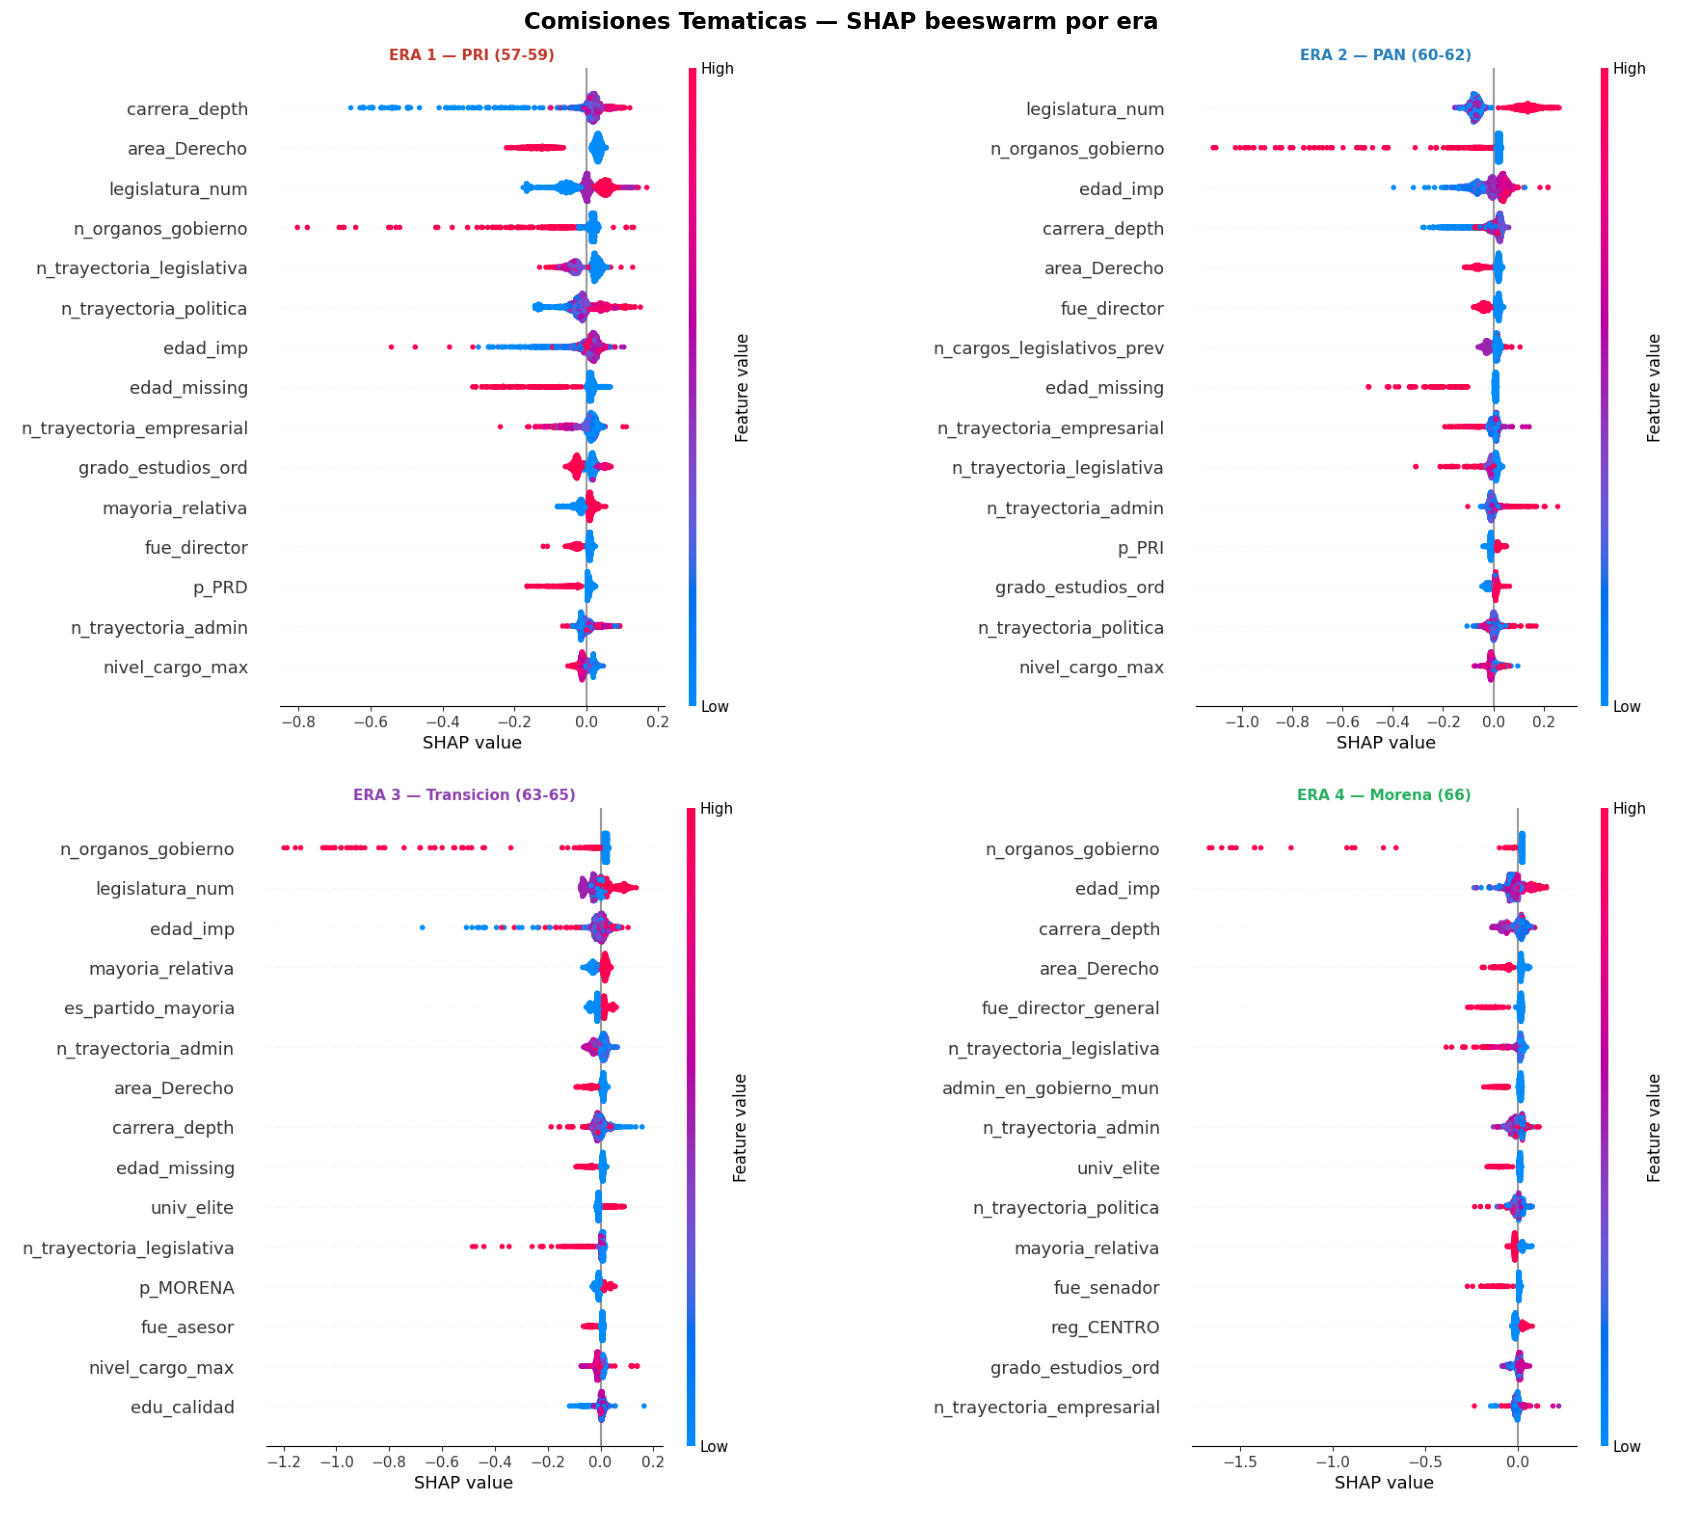

In [18]:
imgs_tem = {era: shap_beeswarm_to_img(
                *shap_tem[era], top_n=15,
                title=ERA_LABELS[era], color=ERA_COLORS[era])
            for era in ERA_ORDER}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
for ax, era in zip(axes.flatten(), ERA_ORDER):
    ax.imshow(imgs_tem[era])
    ax.axis("off")

plt.suptitle("Comisiones Tematicas — SHAP beeswarm por era",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/eda/shap_tematicas_beeswarm.png", bbox_inches="tight", dpi=120)
plt.show()


## 6. Comparacion de Importancias entre Eras

Tabla consolidada: mean(|SHAP|) normalizado para los 3 targets × 4 eras.


In [19]:
def imp_table(shap_dict, top_n=20):
    rows = {era: pd.Series(np.abs(sv).mean(axis=0), index=FEAT_COLS)
            for era, (sv, _) in shap_dict.items()}
    df = pd.DataFrame(rows).rename(columns=ERA_LABELS)
    df["MEDIA"] = df.mean(axis=1)
    return df.sort_values("MEDIA", ascending=False).head(top_n).round(4)

print("=== NODALES ===")
display(imp_table(shap_nodal))

print("\n=== LASTRE ===")
display(imp_table(shap_lastre))

print("\n=== TEMATICAS ===")
display(imp_table(shap_tem))


=== NODALES ===


,ERA 1 — PRI (57-59),ERA 2 — PAN (60-62),ERA 3 — Transicion (63-65),ERA 4 — Morena (66),MEDIA
area_Derecho,0.280,0.316,0.140,0.335,0.268
edad_imp,0.134,0.315,0.206,0.295,0.238
carrera_depth,0.196,0.166,0.124,0.259,0.186
n_trayectoria_legislativa,0.154,0.073,0.151,0.294,0.168
n_trayectoria_empresarial,0.239,0.112,0.115,0.159,0.156
n_trayectoria_politica,0.203,0.107,0.098,0.165,0.143
univ_publica,0.114,0.094,0.119,0.140,0.117
n_trayectoria_admin,0.113,0.089,0.096,0.101,0.100
tiene_posgrado,0.035,0.178,0.137,0.048,0.100
n_organos_gobierno,0.108,0.106,0.072,0.061,0.087



=== LASTRE ===


,ERA 1 — PRI (57-59),ERA 2 — PAN (60-62),ERA 3 — Transicion (63-65),ERA 4 — Morena (66),MEDIA
edad_imp,0.230,0.194,0.235,0.321,0.245
carrera_depth,0.217,0.087,0.179,0.128,0.153
n_trayectoria_admin,0.093,0.168,0.115,0.185,0.140
n_trayectoria_politica,0.108,0.125,0.101,0.212,0.137
n_trayectoria_empresarial,0.079,0.093,0.091,0.195,0.115
n_trayectoria_legislativa,0.054,0.056,0.130,0.145,0.096
fue_diputado_federal,0.006,0.110,0.037,0.225,0.094
mayoria_relativa,0.079,0.104,0.017,0.153,0.088
legislatura_num,0.088,0.168,0.086,0.000,0.086
univ_privada,0.018,0.029,0.111,0.178,0.084



=== TEMATICAS ===


,ERA 1 — PRI (57-59),ERA 2 — PAN (60-62),ERA 3 — Transicion (63-65),ERA 4 — Morena (66),MEDIA
n_organos_gobierno,0.035,0.046,0.044,0.062,0.047
legislatura_num,0.043,0.095,0.033,0.000,0.043
carrera_depth,0.053,0.034,0.016,0.038,0.035
edad_imp,0.033,0.043,0.023,0.041,0.035
area_Derecho,0.052,0.030,0.017,0.035,0.034
n_trayectoria_legislativa,0.033,0.015,0.013,0.032,0.023
n_trayectoria_politica,0.033,0.013,0.009,0.021,0.019
n_trayectoria_admin,0.014,0.014,0.017,0.026,0.018
n_trayectoria_empresarial,0.026,0.017,0.007,0.015,0.016
edad_missing,0.029,0.017,0.015,0.002,0.016


## 7. Validacion Temporal — Rolling Forward

Entrenar en ERA k, predecir ERA k+1.
**AUC cae => el perfil de reclutamiento cambio entre epocas.**


In [20]:
def rolling_forward(target, is_binary=True):
    results = []
    for train_era, test_era in zip(ERA_ORDER[:-1], ERA_ORDER[1:]):
        X_tr, y_tr = get_Xy(train_era, target)
        X_te, y_te = get_Xy(test_era,  target)

        if is_binary:
            m = make_xgb_binary(spw(y_tr))
            m.fit(X_tr, y_tr)
            prob = m.predict_proba(X_te)[:, 1]
            score = roc_auc_score(y_te, prob)
            metric = "AUC"
        else:
            m = make_xgb_poisson()
            m.fit(X_tr, y_tr)
            score = mean_absolute_error(y_te, m.predict(X_te))
            metric = "MAE"

        results.append({
            "Transicion": f"{ERA_LABELS[train_era].split('(')[0].strip()} -> {ERA_LABELS[test_era].split('(')[0].strip()}",
            metric: round(score, 3),
        })
        print(f"  {train_era} -> {test_era}: {metric}={score:.3f}")
    return pd.DataFrame(results)

print("=== NODALES ===")
df_roll_n = rolling_forward("nodal_bin",  is_binary=True)

print("\n=== LASTRE ===")
df_roll_l = rolling_forward("lastre_bin", is_binary=True)

print("\n=== TEMATICAS ===")
df_roll_t = rolling_forward("n_comisiones_tematicas", is_binary=False)


=== NODALES ===
  ERA_1_PRI -> ERA_2_PAN: AUC=0.711


  ERA_2_PAN -> ERA_3_TRANS: AUC=0.652
  ERA_3_TRANS -> ERA_4_MORENA: AUC=0.712

=== LASTRE ===


  ERA_1_PRI -> ERA_2_PAN: AUC=0.615
  ERA_2_PAN -> ERA_3_TRANS: AUC=0.581


  ERA_3_TRANS -> ERA_4_MORENA: AUC=0.615

=== TEMATICAS ===


  ERA_1_PRI -> ERA_2_PAN: MAE=0.867


  ERA_2_PAN -> ERA_3_TRANS: MAE=0.910


  ERA_3_TRANS -> ERA_4_MORENA: MAE=0.806


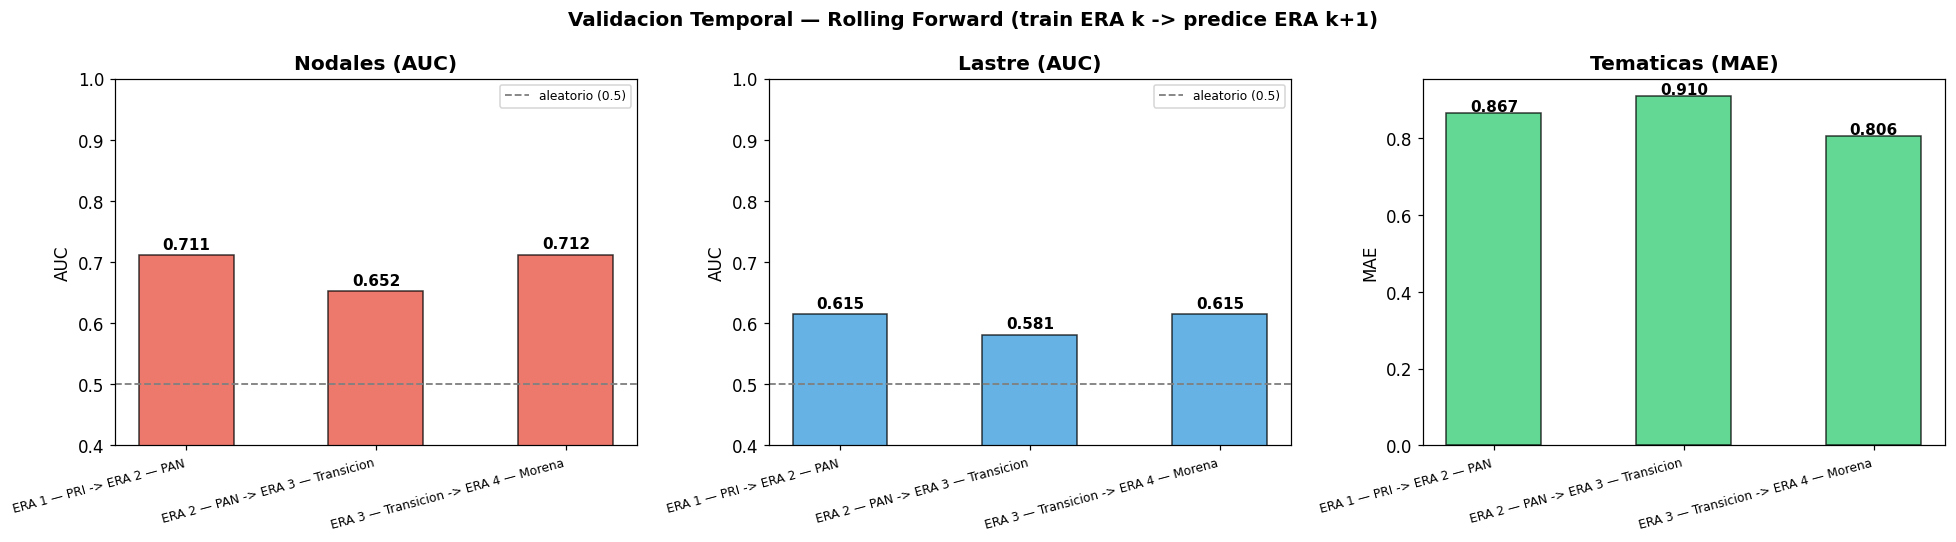

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
specs = [
    (df_roll_n, "Nodales (AUC)",    "#e74c3c", "AUC",  (0.4, 1.0), 0.5),
    (df_roll_l, "Lastre (AUC)",     "#3498db", "AUC",  (0.4, 1.0), 0.5),
    (df_roll_t, "Tematicas (MAE)", "#2ecc71", "MAE",  None,        None),
]

for ax, (df_r, title, color, metric, ylim, hline) in zip(axes, specs):
    xs    = df_r["Transicion"].values
    vals  = df_r[metric].values
    bars  = ax.bar(xs, vals, color=color, alpha=0.75, edgecolor="black", width=0.5)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(metric)
    if ylim:
        ax.set_ylim(*ylim)
    if hline is not None:
        ax.axhline(hline, ls="--", color="gray", lw=1.2, label=f"aleatorio ({hline})")
        ax.legend(fontsize=8)
    for j, v in enumerate(vals):
        ax.text(j, v + (0.01 if metric=="AUC" else 0.005),
                f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")
    ax.tick_params(axis="x", labelsize=8)
    ax.set_xticks(range(len(xs)))
    ax.set_xticklabels(xs, rotation=15, ha="right")

plt.suptitle("Validacion Temporal — Rolling Forward (train ERA k -> predice ERA k+1)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/eda/rolling_validation.png", bbox_inches="tight", dpi=120)
plt.show()


## 8. Perfiles Prototipicos

El diputado con mayor SHAP positivo acumulado en cada era = perfil mas
buscado para comisiones nodales.


In [22]:
DISPLAY_FEATS = [
    "es_partido_mayoria", "n_cargos_legislativos_prev",
    "fue_secretario_cargo", "n_trayectoria_admin",
    "n_trayectoria_politica", "grado_estudios_ord",
    "tiene_posgrado", "univ_elite", "edad_imp",
    "mayoria_relativa", "fue_senador", "nivel_cargo_max",
]

profiles = {}
for era in ERA_ORDER:
    sv, X = shap_nodal[era]
    best  = int(np.argmax(sv.sum(axis=1)))
    profiles[ERA_LABELS[era]] = X.iloc[best][DISPLAY_FEATS]

df_profiles = pd.DataFrame(profiles).T
print("Perfiles prototipicos — 1 diputado por era con mayor SHAP acumulado (Nodales):")
df_profiles


Perfiles prototipicos — 1 diputado por era con mayor SHAP acumulado (Nodales):


,es_partido_mayoria,n_cargos_legislativos_prev,fue_secretario_cargo,n_trayectoria_admin,n_trayectoria_politica,grado_estudios_ord,tiene_posgrado,univ_elite,edad_imp,mayoria_relativa,fue_senador,nivel_cargo_max
ERA 1 — PRI (57-59),0.000,2.000,0.000,4.000,10.000,0.000,1.000,1.000,44.000,0.000,0.000,1.000
ERA 2 — PAN (60-62),1.000,1.000,1.000,13.000,11.000,6.000,1.000,1.000,53.000,0.000,0.000,4.000
ERA 3 — Transicion (63-65),0.000,0.000,1.000,4.000,6.000,0.000,1.000,1.000,50.000,1.000,0.000,4.000
ERA 4 — Morena (66),1.000,3.000,0.000,8.000,4.000,9.000,1.000,1.000,55.000,0.000,1.000,4.000


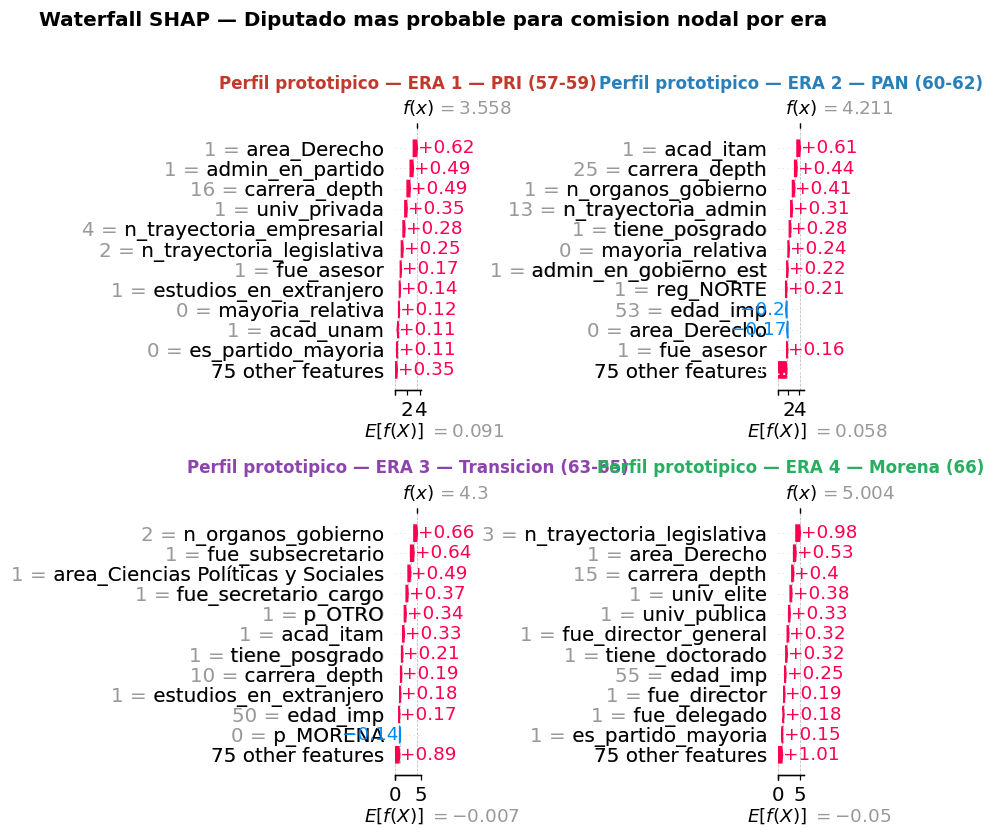

In [23]:
# Waterfall del perfil prototipico en cada era
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for i, era in enumerate(ERA_ORDER):
    sv, X  = shap_nodal[era]
    best   = int(np.argmax(sv.sum(axis=1)))
    exp    = shap.TreeExplainer(models_nodal[era])
    exp_obj= exp(X)

    ax = axes[i]
    plt.sca(ax)
    shap.plots.waterfall(exp_obj[best], max_display=12, show=False)
    ax.set_title(f"Perfil prototipico — {ERA_LABELS[era]}",
                 fontsize=11, fontweight="bold", color=ERA_COLORS[era])

plt.suptitle("Waterfall SHAP — Diputado mas probable para comision nodal por era",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("reports/eda/waterfall_prototipos.png", bbox_inches="tight", dpi=120)
plt.show()


## 9. Tabla Resumen — Todos los Modelos

In [24]:
print("NODALES (AUC — 5-fold CV)")
display(df_nodal_cv)

print("\nLASTRE (AUC — 5-fold CV)")
display(df_lastre_cv)

print("\nTEMATICAS (MAE — 5-fold CV)")
display(pd.DataFrame(rows_tem))


NODALES (AUC — 5-fold CV)


,Era,n,pos%,LR,RF,XGB,best
0,ERA 1 — PRI (57-59),1500,32.2%,0.734+-0.025,0.719+-0.030,0.719+-0.033,LR
1,ERA 2 — PAN (60-62),1500,40.7%,0.720+-0.026,0.725+-0.026,0.718+-0.024,RF
2,ERA 3 — Transicion (63-65),1500,49.5%,0.699+-0.017,0.677+-0.028,0.694+-0.013,LR
3,ERA 4 — Morena (66),500,55.4%,0.619+-0.059,0.643+-0.064,0.602+-0.071,RF



LASTRE (AUC — 5-fold CV)


,Era,n,pos%,LR,RF,XGB,best
0,ERA 1 — PRI (57-59),1500,42.1%,0.585+-0.017,0.601+-0.021,0.585+-0.012,RF
1,ERA 2 — PAN (60-62),1500,45.9%,0.632+-0.039,0.618+-0.020,0.589+-0.030,LR
2,ERA 3 — Transicion (63-65),1500,49.9%,0.583+-0.021,0.617+-0.026,0.606+-0.013,RF
3,ERA 4 — Morena (66),500,39.2%,0.530+-0.035,0.595+-0.064,0.557+-0.060,RF



TEMATICAS (MAE — 5-fold CV)


,Era,n,media,Baseline MAE,GLM Poisson,XGB Poisson,mejora%
0,ERA 1 — PRI (57-59),1500,1.53,0.855,0.803+-0.057,0.785+-0.051,8.2%
1,ERA 2 — PAN (60-62),1500,1.93,0.791,0.791+-0.033,0.795+-0.026,-0.4%
2,ERA 3 — Transicion (63-65),1500,2.15,0.895,0.885+-0.053,0.871+-0.045,2.7%
3,ERA 4 — Morena (66),500,1.87,0.747,0.742+-0.019,0.744+-0.015,0.3%


## 10. Guia de Interpretacion

### AUC
| Rango | Lectura |
|:------|:--------|
| 0.50 | Aleatorio — perfil no predice asignacion |
| 0.55–0.65 | Señal debil — factores no observados dominan |
| 0.65–0.75 | Señal moderada — perfil importa pero no determina |
| 0.75–0.85 | Señal fuerte — perfil es factor relevante |
| > 0.85 | Señal muy fuerte — asignacion casi determinista |

### Preguntas de investigacion
| Q | Test |
|:--|:-----|
| ¿Cambio el perfil de reclutamiento a nodales? | `shap_nodales_trend.png` — si `n_trayectoria_admin` cae y `admin_en_partido` sube en ERA_4 -> si |
| ¿Lastre es imagen espejo de nodales? | `corr_mirror` — si r ~ 1.0 -> si |
| ¿`es_partido_mayoria` domina? | posicion en heatmap SHAP |
| ¿Ruptura ERA_1 -> ERA_4? | `rolling_validation.png` — AUC ERA_3->ERA_4 vs ERA_1->ERA_2 |

### Notas de calidad
- LIX tiene anomalia en `grado_estudios_ord` (avg 1.49 vs ~4 resto) — posible error de captura
- 10.2% nulos en edad imputados por media de legislatura
- ERA_4 n=500 — intervalos mas amplios, interpretar con cautela
- 625 registros son reelecciones validas — no son leakage por era
